<a href="https://colab.research.google.com/github/mgasserr/cats-and-dogs-classification/blob/main/cat_and_dog_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
#gaooooooooooooooooor
# 1. INSTALL & DOWNLOAD DATASET
# ==========================================
!pip install -q kagglehub tensorflow

import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# Download dataset
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

# This specific dataset has nested paths: 'training_set/training_set' and 'test_set/test_set'
train_dir = os.path.join(path, "training_set", "training_set")
test_dir = os.path.join(path, "test_set", "test_set")

# ==========================================
# 2. DATA PIPELINE SETUP
# ==========================================
IMG_SIZE = (224, 224)  # Default sizing for VGG16
BATCH_SIZE = 32

print("\n--- Loading Training and Validation Data ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Loading Test Data ---")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. VGG16 MODEL ARCHITECTURE
# ==========================================
# Load the pre-trained VGG16 base model without its top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base convolutional layers to keep learned features intact
base_model.trainable = False

# Construct custom classification layers on top
model = models.Sequential([
    # VGG16 expects inputs scaled via its own preprocessing function or native VGG16 rescale format
    layers.Lambda(lambda x: tf.keras.applications.vgg16.preprocess_input(x), input_shape=(224, 224, 3)),
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification output (0 = cat, 1 = dog)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\n--- Starting Training ---")
EPOCHS = 5 # Set to a low number for quick validation; scale up if needed.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n--- Evaluating on Test Dataset ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog

--- Loading Training and Validation Data ---
Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.

--- Loading Test Data ---
Found 2023 files belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


--- Starting Training ---
Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 62s 231ms/step - accuracy: 0.9489 - loss: 0.6959 - val_accuracy: 0.9775 - val_loss: 0.2238
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 207ms/step - accuracy: 0.9855 - loss: 0.1074 - val_accuracy: 0.9825 - val_loss: 0.1754
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 84s 218ms/step - accuracy: 0.9884 - loss: 0.1099 - val_accuracy: 0.9813 - val_loss: 0.2073
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 202ms/step - accuracy: 0.9931 - loss: 0.0467 - val_accuracy: 0.9856 - val_loss: 0.1373
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.9952 - loss: 0.0405 - val_accuracy: 0.9800 - val_loss: 0.2234

--- Evaluating on Test Dataset ---
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.9723 - loss: 0.5150

Final Test Accuracy: 97.23%


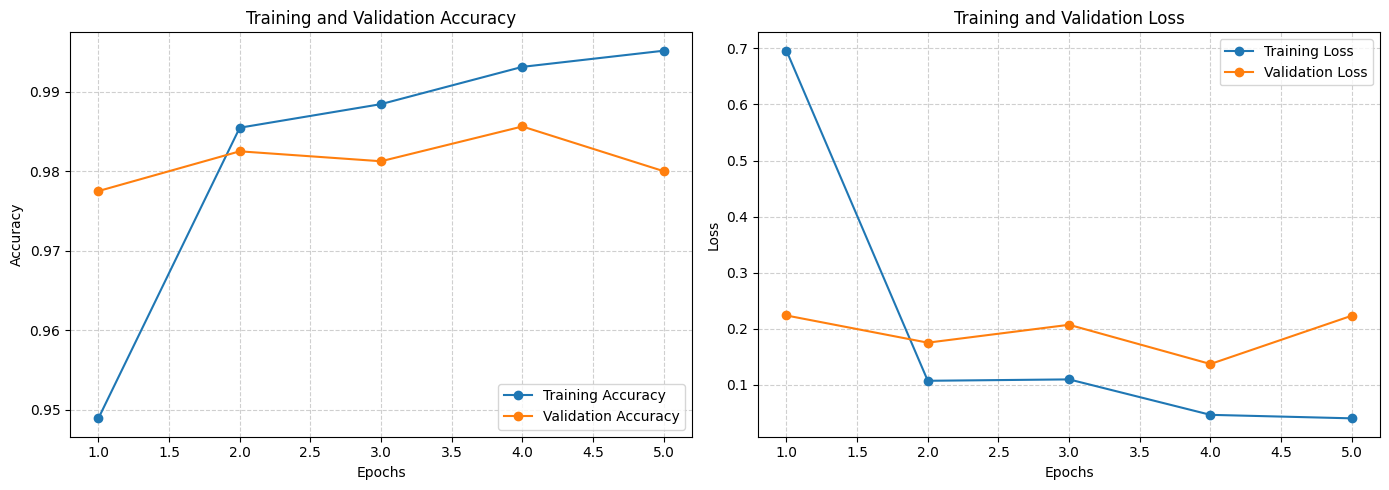

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step


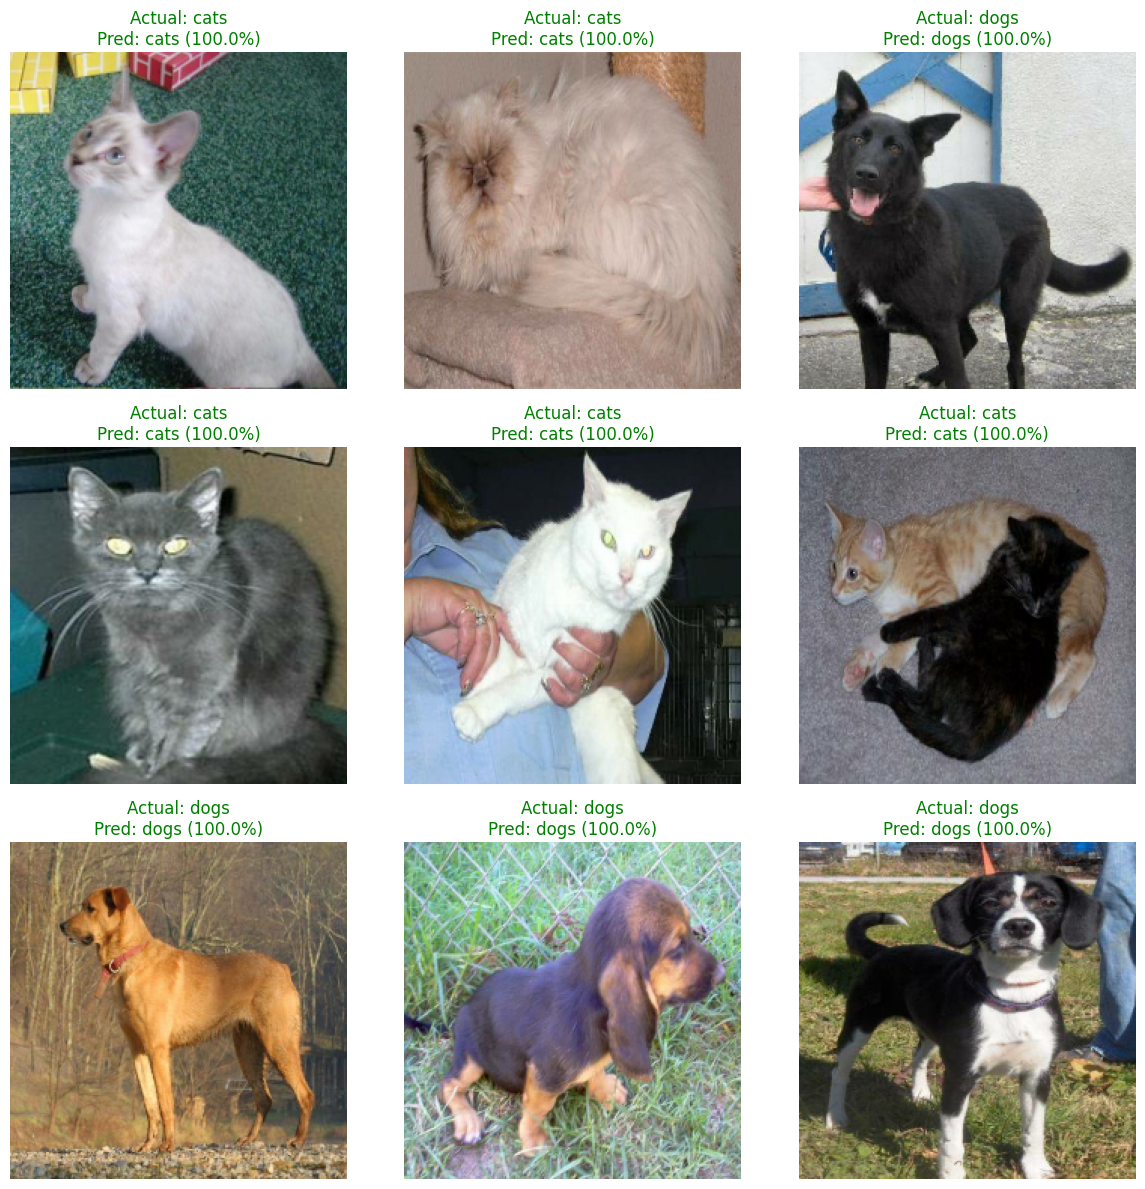

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PLOT ACCURACY AND LOSS CURVES
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 2. VISUALIZE MODEL PREDICTIONS ON TEST DATA
# ==========================================
# Explicitly define the target labels because prefetching hides dataset attributes
class_names = ['cats', 'dogs']

# Take exactly one batch from the test dataset
for images, labels in test_ds.take(1):
    # Get raw probability predictions from the model
    predictions = model.predict(images)

    plt.figure(figsize=(12, 12))
    # Display the first 9 images from the batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Display image (convert tensor back to uint8 for plotting)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Determine actual vs predicted labels
        actual_label = class_names[labels[i]]
        # Sigmoid output > 0.5 is 1 (dog), <= 0.5 is 0 (cat)
        pred_prob = predictions[i][0]
        pred_label = class_names[1 if pred_prob > 0.5 else 0]
        confidence = pred_prob if pred_prob > 0.5 else (1 - pred_prob)

        # Color code the title: Green for correct, Red for incorrect
        title_color = 'green' if pred_label == actual_label else 'red'

        plt.title(f"Actual: {actual_label}\nPred: {pred_label} ({confidence*100:.1f}%)", color=title_color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    model.save('cat_dog_vgg16.h5')